<a href="https://colab.research.google.com/github/Fixer1313/DA_case5/blob/main/notebooks/new_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Исследование факторов, влияющих на длительность госпитализации, диагнозы и затраты в медицинских учреждениях. Предварительная обработка.
##Примечание: данный блок является архивным с 18.08.2026 ввиду предоставления новых данных.

##Импорт библиотек и загрузка датасета

In [ ]:
#import pandas as pd

In [ ]:
#url = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/hospital%20data%20analysis.csv"

In [ ]:
#df = pd.read_csv(url)
#df.head()

##Предварительный обзор

###Первичный осмотр данных

In [ ]:
#print("Форма датасета:", df.shape)

#print("\nИнформация о типах данных:")
#print(df.info())

#print("\nОписательная статистика:")
#print(df[['Age', 'Cost', 'Length_of_Stay', 'Satisfaction']].describe())

###Просмотр уникальных значений по столбцам

In [ ]:
# for col in df.columns:
#   print(f'Столбец: {col}:')
#   print(df[col].value_counts())
#   print('-' * 40)

###Описание переменных

| Переменная | Тип | Описание | Диапазон и количество значений |
|:---|:---|:---|:---|
| **Patient_ID** | int64 | Идентификатор пациента | 984 уникальных записи |
| **Age** | числовая, int64 | Возраст пациента | частичный диапазон от 25 до 78 |
| **Sex** | категориальная, object | Пол пациента |  2 значения: Female - 524 записи, Male - 460 записей |
| **Condition** | категориальная, object | Диагноз | 15 значений |
| **Procedure** | категориальная, object | Проведённое лечение | 15 значений |
| **Cost** | числовая, int64  | Стоимость лечения | 15 значений |
| **Length_of_Stay** | числовая, int64  | Длительность пребывания в стационаре | диапазон от 1 до 76 |
| **Readmission** | категориальная, object | Повторная госпитализация | 2 значения: No - 720 записей, Yes - 264 записи |
| **Outcome** | категориальная, object | Состояние при выписке | 2 значения: Recovered - 591 запись, Stable - 393 записи |
| **Satisfaction** | числовая, int64 | Оценка пациентом проведённого лечения | диапазон от 2 до 5 |

###Первичная визуализация данных для выявления распределения значений и наличия выбросов:

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

In [ ]:
# Построим боксплот для визуализации распределения значений (в частности, выбросов)
# fig, axes = plt.subplots(1, 3, figsize=(12,4))
# for ax, col in zip(axes, ['Age', 'Cost', 'Length_of_Stay']):
#     sns.boxplot(y=df[col], ax=ax)
#     ax.set_title(col)
# plt.tight_layout()
# plt.show()

Выбросы в значениях перменных Age, Cost, Length_of_Stay отсутствуют

In [ ]:
# plt.hist(df['Age'], bins=15, color='skyblue', edgecolor='black')

# plt.xlabel('Age')
# plt.ylabel('Frequency')
# plt.title('Age distribution')
# plt.show()

In [ ]:
# plt.hist(df['Cost'], bins=35, color='skyblue', edgecolor='black')

# plt.xlabel('Cost')
# plt.ylabel('Frequency')
# plt.title('Cost distribution')
# plt.show()

In [ ]:
# plt.hist(df['Length_of_Stay'], bins=20, color='seagreen', edgecolor='black')

# plt.xlabel('Length of stay')
# plt.ylabel('Frequency')
# plt.title('Length of stay distribution, days')
# plt.show()

In [ ]:
# df['Condition'].value_counts().plot.barh()

In [ ]:
# df['Procedure'].value_counts().plot.barh()

Датасет содержит информацию о 984 наблюдениях и 10 признаках (5 - числовых, 5 - категориальных). Одна строка соответствует одному случаю госпитализации. Пропущенные значения и выбросы на данном этапе не обнаружены. Типы данных соответствуют смыслу переменных. Из описательной статистики исключен признак Patient_ID, как не представляющий интерес для статистической интерпретации.

Предварительно можно сделать вывод, что датасет структурно подготовлен для дальнейшего анализа.

##Поиск проблем качества данных

In [ ]:
# # 1. Дубликаты по всем столбцам и по Patient_ID
# print("Полные дубликаты строк:", df.duplicated().sum())
# print("Дубликаты Patient_ID:", df['Patient_ID'].duplicated().sum())

In [ ]:
# # 2. Проверка недостающих значений идентификаторов пациентов
# expected_ids = set(range(df['Patient_ID'].min(), df['Patient_ID'].max() + 1))
# missing_ids = sorted(expected_ids - set(df['Patient_ID']))
# print("Пропущенные Patient_ID:", missing_ids)

In [ ]:
# # 3. Связь Condition, Procedure и Cost между собой
# # (Уникальных записей в каждом из этих столбцов 15)
# unique_per_condition = df.groupby('Condition').agg(
#     unique_procedures=('Procedure', 'nunique'),
#     unique_costs=('Cost', 'nunique')
# )
# print(unique_per_condition)

Cost и Procedure не индивидуальны для пациента, а жестко привязаны к диагнозу (вероятно, справочные значения)

##Подготовка к изменениям

In [ ]:
#  #1. Копия датафрейма для последующих изменений
# df_prep = df.copy()

In [ ]:
# #2. Приведение названий столбцов к нижнему регистру
# df_prep.columns = df_prep.columns.str.lower()

In [ ]:
# #3. Замена всех столбцов с типом object на category
# object_cols = df_prep.select_dtypes(include='object').columns
# df_prep[object_cols] = df_prep[object_cols].astype('category')

In [ ]:
# #4. Замена типа столбца cost на float64
# df_prep['cost'] = df_prep['cost'].astype('float64')

In [ ]:
# #5. Проверка после изменений
# print(df_prep.head())

# print(df_prep.info())

##Трансформации

In [ ]:
# # 1. Создание дополнительного категориального признака Age_Group
# df_prep['age_group'] = pd.cut(
#     df_prep['age'],
#     bins=[24, 34, 44, 54, 64, 100],
#     labels=['25–34', '35–44', '45–54', '55–64', '65+']
# )

Создан дополнительный категориальный признак Age_Group, разделяющий пациентов на возрастные группы для проверки гипотезы о наличии различий в стоимости лечения между пациентами разных возрастных диапазонов.

In [ ]:
# # 2. Создание числового признака переменной Readmission
# df_prep['readmission_flag'] = df_prep['readmission'].map({
#     'No': 0,
#     'Yes': 1
# })

Создан числовой признак переменной Readmission (повторная госпитализация) для упрощения дальнейших расчётов и построения статистических моделей.

In [ ]:
# # 3. Создание числового признака стоимости одного дня госпитализации
# df_prep['cost_per_day'] = df_prep['cost'] / df_prep['length_of_stay']

Признак cost_per_day необходим для дальнейших рассчётов с учётом необходимости рекомендаций по оптимизации.

In [ ]:
# print(df_prep[['age_group', 'readmission_flag', 'cost_per_day']].isna().sum())


После создания age_group, readmission_flag, cost_per_day не возникли NaN.

In [ ]:
# df_prep.head()

In [ ]:
# # Сохраним обработанный датасет в csv
# df_prep.to_csv('hospital_data_prepared.csv', index=False)

#Кейс 5. Исследование факторов, влияющих на длительность госпитализации, диагнозы и затраты в медицинских учреждениях.
#Предварительная обработка. Новые данные (от 18.08.2026).

Новый набор данных состоит из трёх файлов:
- `hospital_admissions_enriched.csv` — основной датасет: пациенты, госпитализации, диагнозы, затраты по статьям (уровень одной госпитализации);
- `department_daily_load.csv` — загрузка отделений по дням: койки, врачи, медсёстры, экстренные поступления (уровень одного дня для одного отделения);
- `hospital_data_dictionary.csv` — словарь данных c описанием каждого поля, допустимыми значениями, признаком `Nullable` и ключами для объединения.

**Порядок работы:** сначала предобрабатываем `hospital_admissions_enriched.csv` и `department_daily_load.csv` отдельно; потом объединяем по общему ключу `Admission_Date`/`Date` + `Department` — так рекомендует и сам словарь данных (см. поле `Key_Role`).

##Импорт библиотек

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

##Предварительно - просмотр словаря данных

In [ ]:
url_0 = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/hospital_data_dictionary.csv"

In [ ]:
df_0 = pd.read_csv(url_0)
print(df_0.shape)

(47, 6)


In [ ]:
df_0.head(47)

,File,Column,Description,Unit_or_Values,Nullable,Key_Role
0,hospital_admissions_enriched.csv,Patient_ID,Synthetic patient identifier; may repeat acros...,integer,No,Patient key
1,hospital_admissions_enriched.csv,Age,Patient age at the first observed admission,years,No,NaN
2,hospital_admissions_enriched.csv,Gender,Recorded gender,Female; Male,No,NaN
3,hospital_admissions_enriched.csv,Condition,Primary condition for the admission,15 condition categories,No,NaN
4,hospital_admissions_enriched.csv,Procedure,Primary procedure or treatment category,categorical,No,NaN
5,hospital_admissions_enriched.csv,Cost,Total actual cost of the admission; sum of ava...,EUR,No,NaN
6,hospital_admissions_enriched.csv,Length_of_Stay,Number of days from admission to discharge,days,No,NaN
7,hospital_admissions_enriched.csv,Readmission,Whether the next admission occurs within 30 da...,Yes; No; blank if follow-up is incomplete,Yes,NaN
8,hospital_admissions_enriched.csv,Outcome,Status at the end of the admission,Recovered; Stable; Transferred; Deceased,No,NaN
9,hospital_admissions_enriched.csv,Satisfaction,Patient satisfaction score,1 (low) to 5 (high),Yes,NaN


Основные моменты для обоих датасетов согласно словарю:
1. Столбцы с возможными нулевыми значениями (по разным причинам): `hospital_admissions_enriched.csv`- Readmission, Satisfaction, Region, Comorbidities, Procedure_Complexity, Procedure_Date, 	Procedure_Wait_Days, 	Diagnostic_Cost_EUR и Days_to_Readmission;
2. В Admission_ID вероятно будут содержаться дубликаты;

##Часть 1. Предобработка датасета `hospital_admissions_enriched.csv`

In [ ]:
url_1 = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/hospital_admissions_enriched.csv"

In [ ]:
df_1 = pd.read_csv(url_1)
print(df_1.shape)

(2941, 37)


In [ ]:
print(df_1.head())

   Patient_ID  Age  Gender              Condition               Procedure      Cost  Length_of_Stay Readmission    Outcome  Satisfaction  \
0         113   41  Female                 Cancer       Radiation Therapy  20776.44              11          No  Recovered           4.0   
1         170   90  Female  Respiratory Infection    Antibiotics and Rest   7865.80               8          No  Recovered           5.0   
2          23   90    Male                 Stroke  CT Scan and Medication  19637.66              15          No  Recovered           5.0   
3        1644   51  Female  Respiratory Infection    Antibiotics and Rest   8665.59               9         Yes     Stable           4.0   
4        1277   42  Female             Childbirth       Surgical Delivery  14320.66               8          No     Stable           5.0   

  Admission_ID  Episode_Number Age_Group   Region                                      Comorbidities  Comorbidity_Count  Comorbidity_Index  \
0      A000147   

In [ ]:
print("\nИнформация о типах данных:")
print(df_1.info())


Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2941 entries, 0 to 2940
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             2941 non-null   int64  
 1   Age                    2941 non-null   int64  
 2   Gender                 2941 non-null   object 
 3   Condition              2941 non-null   object 
 4   Procedure              2941 non-null   object 
 5   Cost                   2941 non-null   float64
 6   Length_of_Stay         2941 non-null   int64  
 7   Readmission            2907 non-null   object 
 8   Outcome                2941 non-null   object 
 9   Satisfaction           2817 non-null   float64
 10  Admission_ID           2941 non-null   object 
 11  Episode_Number         2941 non-null   int64  
 12  Age_Group              2941 non-null   object 
 13  Region                 2913 non-null   object 
 14  Comorbidities          2883 

###1.1. Подготовка к обработке. Приведение названий столбцов к общепринятому виду

In [ ]:
 #1. Копия датафрейма для последующих изменений
df_1_prep = df_1.copy()

In [ ]:
#2. Приведение названий столбцов к нижнему регистру
df_1_prep.columns = df_1_prep.columns.str.lower()

In [ ]:
#3. Проверка после изменений
print(df_1_prep.head())

   patient_id  age  gender              condition               procedure      cost  length_of_stay readmission    outcome  satisfaction  \
0         113   41  Female                 Cancer       Radiation Therapy  20776.44              11          No  Recovered           4.0   
1         170   90  Female  Respiratory Infection    Antibiotics and Rest   7865.80               8          No  Recovered           5.0   
2          23   90    Male                 Stroke  CT Scan and Medication  19637.66              15          No  Recovered           5.0   
3        1644   51  Female  Respiratory Infection    Antibiotics and Rest   8665.59               9         Yes     Stable           4.0   
4        1277   42  Female             Childbirth       Surgical Delivery  14320.66               8          No     Stable           5.0   

  admission_id  episode_number age_group   region                                      comorbidities  comorbidity_count  comorbidity_index  \
0      A000147   

###1.2. Дубликаты.

Исходя из словаря, admission_id уникален "до того, как в файл подмешали задвоенные строки". На основе этого делаем проверку:

In [ ]:
print('Полных дублей строк:', df_1_prep.duplicated().sum())
print('Повторов admission_id:', df_1_prep['admission_id'].duplicated().sum())

Полных дублей строк: 12
Повторов admission_id: 12


Если всего дублей 12, и их количество совпадает с повторами admission_id - то просто удаляем эти строки.

In [ ]:
before = len(df_1_prep)
df_1_prep = df_1_prep.drop_duplicates()
print('Удалили строк:', before - len(df_1_prep), '- осталось:', len(df_1_prep))

Удалили строк: 12 - осталось: 2929


###1.3. Приведение дат к правильному формату + проверка расхождения length_of_stay с разницей admission_date и discharge_date

In [ ]:
#1. Приведение дат к правильному формату
df_1_prep['admission_date'] = pd.to_datetime(df_1_prep['admission_date'])
df_1_prep['discharge_date'] = pd.to_datetime(df_1_prep['discharge_date'])
df_1_prep['procedure_date'] = pd.to_datetime(df_1_prep['procedure_date'])

In [ ]:
#2. Проверка возможного расхождения length_of_stay с разницей admission_date и discharge_date
los_check = (df_1_prep['discharge_date'] - df_1_prep['admission_date']).dt.days
print('Строк, где length_of_stay не совпал с расчётом:', (los_check != df_1_prep['length_of_stay']).sum())

Строк, где length_of_stay не совпал с расчётом: 0


length_of_stay полностью совпадает с разницей дат.

###1.4. Обработка пропусков

In [ ]:
#1. Проверка пропусков
missing_counts = df_1_prep.isna().sum()
missing_percent = (missing_counts / len(df_1_prep)*100).round(2)

missing_summary = pd.DataFrame({
    'Пропусков': missing_counts,
    'Доля_%': missing_percent
})

missing_summary = missing_summary[missing_summary['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
print(missing_summary)

                      Пропусков  Доля_%
days_to_readmission        2422   82.69
satisfaction                123    4.20
comorbidities                58    1.98
procedure_wait_days          43    1.47
procedure_date               43    1.47
readmission                  34    1.16
diagnostic_cost_eur          29    0.99
region                       28    0.96
procedure_complexity         22    0.75


<Axes: >

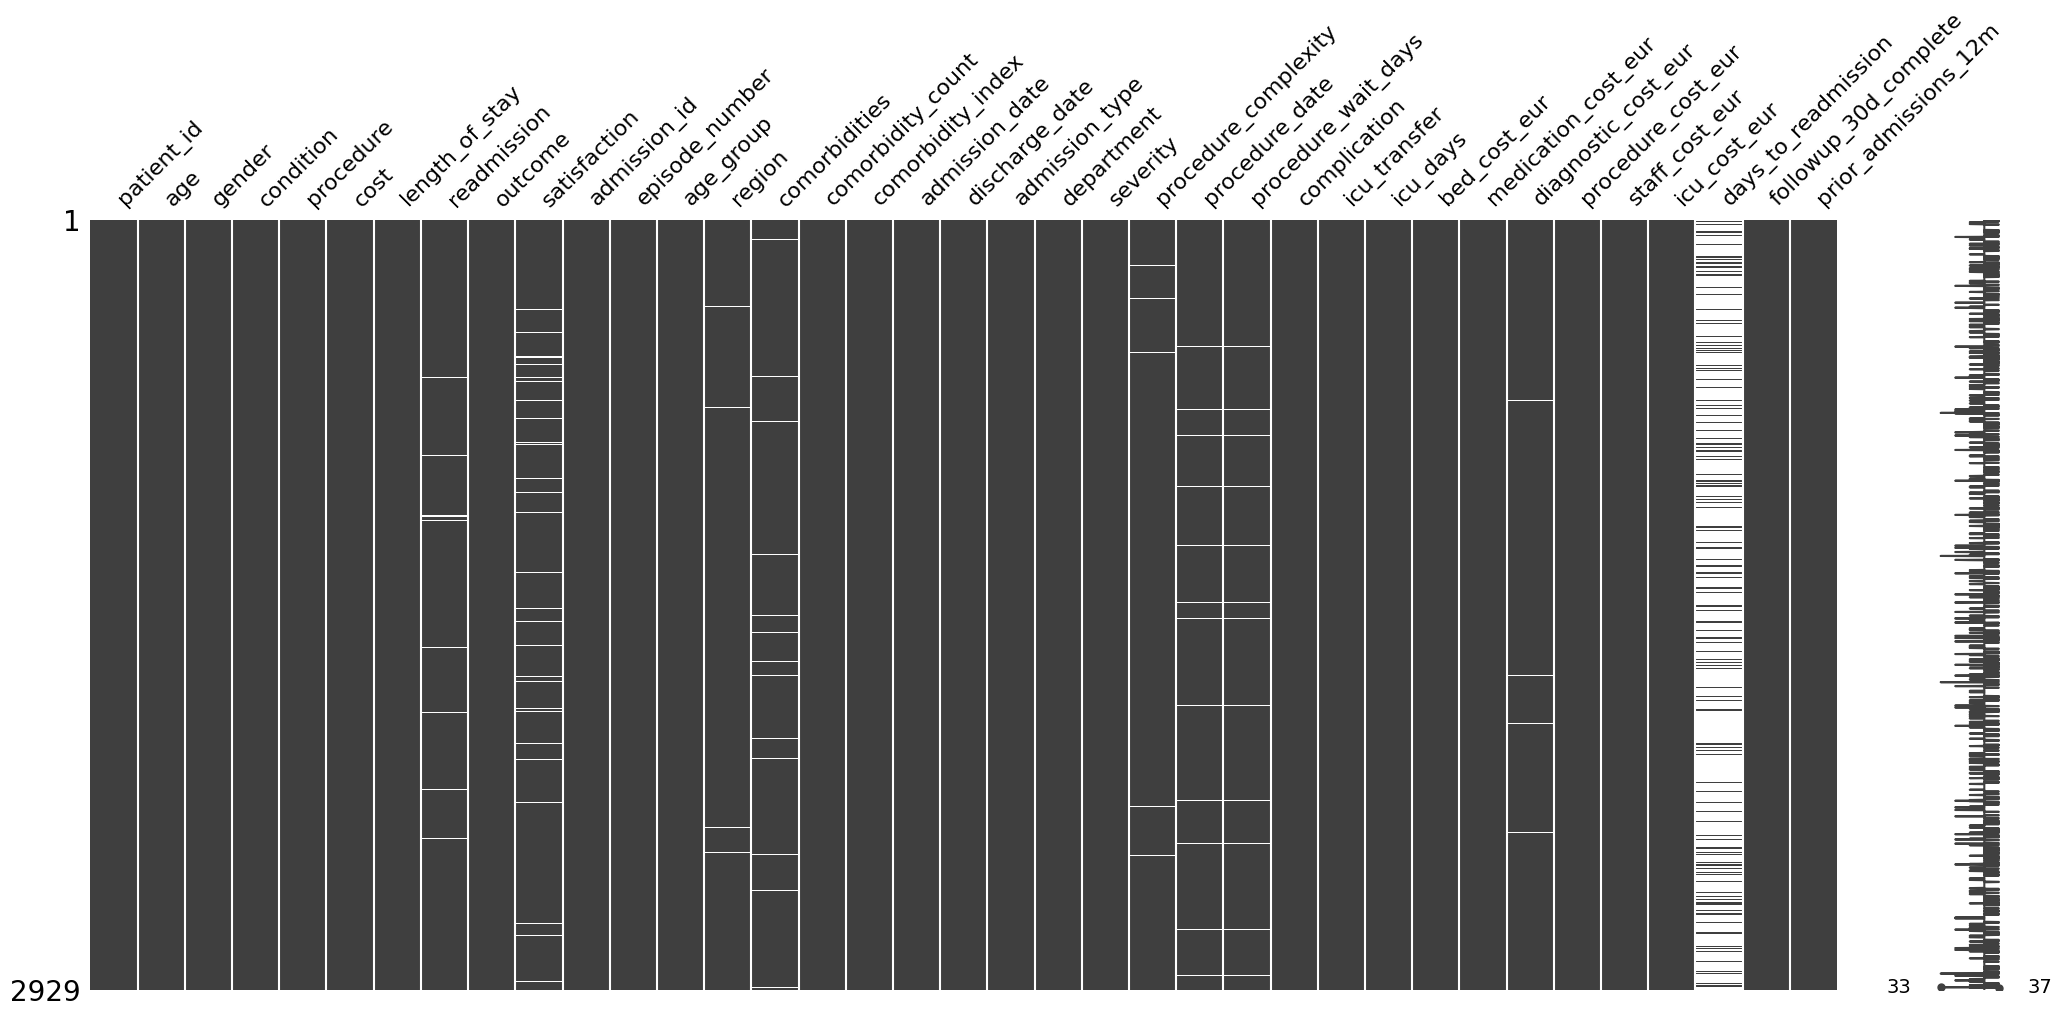

In [ ]:
import missingno

missingno.matrix(df_1_prep)

Пропуски сопадают с информацией из словаря. Больше всего пропусков у Days_to_Readmission (82.69%), но это не ошибка с точки зрения данных. Остальные поля с небольшой долей пропусков.

In [ ]:
#2. Заполнение пропусков

# Убедимся в уникальности уровня сложности процедуры независимо от пациента
df_1.groupby('Procedure')['Procedure_Complexity'].unique()

,Procedure_Complexity
Procedure,
Angioplasty,"[High, nan]"
Antibiotics and Rest,"[Low, nan]"
Appendectomy,"[High, nan]"
CT Scan and Medication,"[Moderate, nan]"
Cardiac Catheterization,"[High, nan]"
Cast and Physical Therapy,[Moderate]
Delivery and Postnatal Care,[Moderate]
Diagnostic Workup,"[Low, nan]"
Epinephrine Injection,"[Low, nan]"


In [ ]:
# procedure_complexity заполняем известными значениями сложности процедуры у пациентов с аналогичным типом процедуры
df_1_prep['procedure_complexity'] = (
    df_1_prep['procedure_complexity'].fillna(
        df_1_prep.groupby(
            'procedure',
            observed=True
        )['procedure_complexity']
        .transform('first'))
)

# Если readmission пустой, то наблюдение ещё не закончилось
df_1_prep['readmission'] = df_1_prep['readmission'].fillna('follow-up incomplete')

# region пустой - просто помечаем как unknown
df_1_prep['region'] = df_1_prep['region'].fillna('unknown')

# comorbidities пустой - тоже unknown (это не то же самое, что "нет сопутствующих болезней", для этого случая в есть отдельная категория 'No recorded comorbidities')
df_1_prep['comorbidities'] = df_1_prep['comorbidities'].fillna('unknown')

# procedure_date и procedure_wait_days пустые - значит процедуры просто не было. Делаем отдельный столбец True/False - была процедура или нет
df_1_prep['has_procedure'] = df_1_prep['procedure_date'].notna()

# Если days_to_readmission пустой, то повторной госпитализации не было. Не трогаем.

# satisfaction - пропусков мало, поэтому просто заполняем медианой по диагнозу.

median_satisfaction = df_1_prep.groupby('condition', observed=True)['satisfaction'].transform('median')
df_1_prep['satisfaction'] = df_1_prep['satisfaction'].fillna(median_satisfaction)

# Пропуски в diagnostic_cost_eur заполняем разницей между cost и остальными компонентами, входящими в cost
missing_diagnostic_cost = df_1_prep['diagnostic_cost_eur'].isna()
df_1_prep.loc[missing_diagnostic_cost, 'diagnostic_cost_eur'] = (
    df_1_prep.loc[missing_diagnostic_cost, 'cost']
    - df_1_prep.loc[missing_diagnostic_cost, 'bed_cost_eur']
    - df_1_prep.loc[missing_diagnostic_cost, 'medication_cost_eur']
    - df_1_prep.loc[missing_diagnostic_cost, 'procedure_cost_eur']
    - df_1_prep.loc[missing_diagnostic_cost, 'staff_cost_eur']
    - df_1_prep.loc[missing_diagnostic_cost, 'icu_cost_eur'])

###1.5. Приведение типов данных

In [ ]:
categorical_cols = ['gender', 'condition', 'procedure', 'readmission', 'outcome',
                     'age_group', 'region', 'admission_type', 'department', 'severity',
                     'procedure_complexity', 'complication', 'icu_transfer']

for col in categorical_cols:
    df_1_prep[col] = df_1_prep[col].astype('category')

### 1.6. Трансформации

In [ ]:
# Рассчитаем долю каждого компонента в общей стоимости госпитализации
# Предварительно проверим согласованность общей стоимости лечения с каждым компонентом

# Сумма всех компонентов расходов
df_1_prep['calculated_cost'] = (
    df_1_prep['bed_cost_eur'] +
    df_1_prep['medication_cost_eur'] +
    df_1_prep['diagnostic_cost_eur'] +
    df_1_prep['procedure_cost_eur'] +
    df_1_prep['staff_cost_eur'] +
    df_1_prep['icu_cost_eur']
)

# Разница между исходной общей стоимостью и рассчитанной суммой
df_1_prep['cost_difference'] = (df_1_prep['cost'] - df_1_prep['calculated_cost'])

# Проверяем, сколько строк не сходится
print('Количество несовпадений:', (df_1_prep['cost_difference'].abs() > 0.01).sum())

# Показываем строки, где есть расхождение
print(df_1_prep.loc[df_1_prep['cost_difference'].abs() > 0.01,
      ['cost','calculated_cost','cost_difference']])

Количество несовпадений: 0
Empty DataFrame
Columns: [cost, calculated_cost, cost_difference]
Index: []


In [ ]:
# Несовпадения не выявлены. Перейдем к рассчетам
cost_components = ['bed_cost_eur',
                   'medication_cost_eur',
                   'diagnostic_cost_eur',
                   'procedure_cost_eur',
                   'staff_cost_eur',
                   'icu_cost_eur']

for column in cost_components:
  new_column = (column.replace('_eur', '_share'))
  df_1_prep[new_column] = (df_1_prep[column]/df_1_prep['cost'])

In [ ]:
df_1.to_csv('hospital_admissions_clean.csv', index=False)

### Часть 2. Предобработка `department_daily_load.csv`




In [ ]:
url_2 = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/department_daily_load.csv"

In [ ]:
df_2 = pd.read_csv(url_2)

In [ ]:
print(df_2.head)

<bound method NDFrame.head of             Date         Department  Available_Beds  Occupied_Beds  Bed_Occupancy_Rate  Doctors_Planned  Doctors_On_Duty  Nurses_Planned  \
0     2022-01-01         Cardiology              44             36              0.8182                4                4               9   
1     2022-01-01    General Surgery              42             31              0.7381                4                4               9   
2     2022-01-01  Internal Medicine              64             58              0.9062                6                6              13   
3     2022-01-01          Neurology              36             29              0.8056                4                4               8   
4     2022-01-01         Obstetrics              40             29              0.7250                4                4               8   
...          ...                ...             ...            ...                 ...              ...              ...          

In [ ]:
print("\nИнформация о типах данных:")
print(df_2.info())


Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9008 entries, 0 to 9007
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  9008 non-null   object 
 1   Department            9008 non-null   object 
 2   Available_Beds        9008 non-null   int64  
 3   Occupied_Beds         9008 non-null   int64  
 4   Bed_Occupancy_Rate    9008 non-null   float64
 5   Doctors_Planned       9008 non-null   int64  
 6   Doctors_On_Duty       9008 non-null   int64  
 7   Nurses_Planned        9008 non-null   int64  
 8   Nurses_On_Duty        9008 non-null   int64  
 9   Emergency_Admissions  9008 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 703.9+ KB
None


Пропуски отсутствуют. Проверим на дубликаты:

In [ ]:
print('Дублей по Date+Department:', df_2.duplicated(subset=['Date', 'Department']).sum())
print('Полных дублей строк:', df_2.duplicated().sum())

Дублей по Date+Department: 0
Полных дублей строк: 0


Датасет чистый. Выполним смену типов данных (Date на datetime, Department на category), названия столбцов приведём к нижнему регистру.

###2.1 Обработка второго датасета

In [ ]:
 #1. Копия датафрейма для последующих изменений
df_2_prep = df_2.copy()

In [ ]:
#2. Приведение названий столбцов к нижнему регистру
df_2_prep.columns = df_2_prep.columns.str.lower()

In [ ]:
#3. Смена типов данных столбцов Date и Department
df_2_prep['date'] = pd.to_datetime(df_2_prep['date'])
df_2_prep['department'] = df_2_prep['department'].astype('category')

In [ ]:
#Просмотр датасета после изменений
print(df_2_prep.head)
print("\nИнформация о типах данных:")
print(df_2_prep.info())

<bound method NDFrame.head of            date         department  available_beds  occupied_beds  bed_occupancy_rate  doctors_planned  doctors_on_duty  nurses_planned  \
0    2022-01-01         Cardiology              44             36              0.8182                4                4               9   
1    2022-01-01    General Surgery              42             31              0.7381                4                4               9   
2    2022-01-01  Internal Medicine              64             58              0.9062                6                6              13   
3    2022-01-01          Neurology              36             29              0.8056                4                4               8   
4    2022-01-01         Obstetrics              40             29              0.7250                4                4               8   
...         ...                ...             ...            ...                 ...              ...              ...             ... 

### 2.2. Трансформации

In [ ]:
# Добавим переменные, отражающие степень укомплектованности отделений персоналом
df_2_prep['doctor_coverage_rate'] = (df_2_prep['doctors_on_duty']/df_2_prep['doctors_planned'])
df_2_prep['nurse_coverage_rate'] = (df_2_prep['nurses_on_duty']/df_2_prep['nurses_planned'])

print(df_2_prep.head)

<bound method NDFrame.head of            date         department  available_beds  occupied_beds  bed_occupancy_rate  doctors_planned  doctors_on_duty  nurses_planned  \
0    2022-01-01         Cardiology              44             36              0.8182                4                4               9   
1    2022-01-01    General Surgery              42             31              0.7381                4                4               9   
2    2022-01-01  Internal Medicine              64             58              0.9062                6                6              13   
3    2022-01-01          Neurology              36             29              0.8056                4                4               8   
4    2022-01-01         Obstetrics              40             29              0.7250                4                4               8   
...         ...                ...             ...            ...                 ...              ...              ...             ... 

Полученные значения показывают долю фактически работающего персонала относительно плановой численности. Значение 1.0 соответствует 100% укомплектованности.

In [ ]:
df_2.to_csv('department_daily_load_clean.csv', index=False)

### 3. Объединение таблиц

In [ ]:
# Объединим предобработанные таблицы для удобства манипуляций с данными
# В словаре указано, что объединение предусмотрено по полям admission_date, department.
# В датасете df_2_prep фигурирует переменная date. Для совпадения первичного ключа требуется переименование в admission_date.
df_2_for_merge = df_2_prep.rename(
    columns={'date': 'admission_date'})

df_2_for_merge.info()

# Производим объединение
df_merged = df_1_prep.merge(
    df_2_for_merge,
    on=['admission_date',
        'department'],
    how='left')

# Производим проверку
print('Размер df_1_prep:', df_1_prep.shape)
print('Размер df_2_prep:', df_2_prep.shape)
print('Размер объединённой таблицы:', df_merged.shape)

print(df_merged.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9008 entries, 0 to 9007
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   admission_date        9008 non-null   datetime64[ns]
 1   department            9008 non-null   category      
 2   available_beds        9008 non-null   int64         
 3   occupied_beds         9008 non-null   int64         
 4   bed_occupancy_rate    9008 non-null   float64       
 5   doctors_planned       9008 non-null   int64         
 6   doctors_on_duty       9008 non-null   int64         
 7   nurses_planned        9008 non-null   int64         
 8   nurses_on_duty        9008 non-null   int64         
 9   emergency_admissions  9008 non-null   int64         
 10  doctor_coverage_rate  9008 non-null   float64       
 11  nurse_coverage_rate   9008 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3), int64(7)
memory usage: 783.4 

In [ ]:
df_merged.to_csv('merged_data.csv', index=False)

In [ ]:
url_1_cleaned = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/hospital_admissions_clean.csv"

In [ ]:
url_2_cleaned = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/department_daily_load_clean.csv"

In [ ]:
url_merged = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/merged_data.csv"